## What this notebook does

Accumulated rainfall — how much rain fell over a place between two dates — is
one of the most requested numbers in agricultural water management. It is what
sits behind a sowing-window advisory, a dry-spell alert, a reservoir inflow
estimate and a seasonal rainfall anomaly.

This notebook produces it. You choose an area, a start date and an end date, and
it returns a map of total rainfall in millimetres, a day-by-day chart of how the
season built up, and a GeoTIFF you can take into anything else — from one of two
global satellite products:

| Source | Resolution | Cadence | Record |
| --- | --- | --- | --- |
| [GPM IMERG V07]({{ site.baseurl }}/datasets/gpm-imerg/) | ~11 km | half-hourly | 1998 to present |
| [CHIRPS Daily]({{ site.baseurl }}/datasets/chirps/) | ~5 km | daily | 1981 to present |

Nothing is downloaded to your machine. Earth Engine holds both archives and does
the summing on Google's servers; what comes back is a picture and a few numbers.

**Read the section on units before you trust a total.** The two products store
rainfall in different units, and adding up the wrong one gives an answer that is
out by a factor of two. That is the single most common mistake in this workflow,
and section 6 explains how to avoid it.

## 1. Getting access to Earth Engine

Earth Engine is free for research, education and non-profit use, but access is
not automatic — every request is routed through a **Google Cloud project**, and
that project has to be registered. This takes about ten minutes, once.

### Step 1 — register a project

Go to the [Earth Engine registration page](https://console.cloud.google.com/earth-engine)
and sign in with your Google account. The page will offer to create a new Cloud
project and register it in one flow, which is the route Google recommends.

When it asks how you will use Earth Engine, choose
[**noncommercial**](https://earthengine.google.com/noncommercial) if your work is
research, education or non-profit. You will be asked to complete a short
eligibility questionnaire. Access is enabled as soon as registration finishes —
there is no waiting list.

If your organisation restricts who may create Cloud projects, ask your IT
administrator either to grant you the permission or to create and register a
project for you. This is common in institutional accounts.

### Step 2 — find your project ID

The **project ID** is the string you will paste into the code below. It is not
the display name, and the two are often different.

- Google suggests the naming convention `ee-` followed by your usual username,
  so a typical ID looks like `ee-yourname`.
- To look it up, open the
  [Cloud Resource Manager](https://console.cloud.google.com/cloud-resource-manager).
  Every project you can see is listed with its **ID** in its own column.
- It is also shown in the project picker at the top of any Google Cloud Console
  page, and in the URL as `?project=your-project-id`.

An ID is lowercase, may contain digits and hyphens, and cannot be changed after
the project is created.

### Step 3 — check the Earth Engine API is on

If you registered through the page above this is already done. If you registered
an existing project by hand, open the
[Earth Engine API page](https://console.cloud.google.com/apis/library/earthengine.googleapis.com),
select your project, and click **Enable**.

**Reference:** Google's own pages on
[Earth Engine access](https://developers.google.com/earth-engine/guides/access)
and
[authentication and initialization](https://developers.google.com/earth-engine/guides/auth)
are the authority here, and are kept current.

## 2. Install the libraries

On **Google Colab** the Earth Engine library is already installed and only
`geemap` is missing. Remove the `#` from the line below and run the cell.

Working **locally**, install both into your environment first:

```bash
pip install earthengine-api geemap
```

`geemap` is the interactive-map layer over Earth Engine; see its
[documentation](https://geemap.org/) for what else it can do.

In [1]:
# In Colab, uncomment this line and run the cell once per session:
# !pip install geemap -q

import ee
import geemap
import matplotlib.pyplot as plt
import pandas as pd

## 3. Authenticate, and say which project to bill

Two separate things happen here, and it is worth knowing which is which:

- `ee.Authenticate()` proves **who you are**. It opens a Google sign-in page and
  stores a token, so you normally only do this once per machine. In Colab it is
  once per session.
- `ee.Initialize(project=...)` says **which project the work is charged to**.
  This argument is required — Earth Engine will not run without it.

Replace the placeholder below with the project ID you found in step 2.

In [ ]:
# ── Replace this with your own project ID from step 2 ──────────────────────
PROJECT_ID = "ee-your-project-id"
# ──────────────────────────────────────────────────────────────────────────

ee.Authenticate()          # add force=True to sign in as a different account
ee.Initialize(project=PROJECT_ID)

print(f"Earth Engine is ready, using project: {PROJECT_ID}")

**If this fails,** section 13 lists the errors people actually hit, with what
each one means.

Never commit a notebook containing a real project ID to a public repository if
that project is billed. It is not a secret in the way an API key is, but it does
identify your account.

## 4. Choose the area, the dates and the source

Everything you would normally want to change lives in this one cell. Nothing
below it needs editing for a different country or season.

**Area.** A rectangle is given as `[west, south, east, north]` in degrees —
longitude first, then latitude, with west and south negative. The default is a
box over the Ganges–Brahmaputra plain. Some others to try:

| Area | west, south, east, north |
| --- | --- |
| Bangladesh | `[88.0, 20.6, 92.7, 26.6]` |
| Sri Lanka | `[79.6, 5.8, 82.0, 10.0]` |
| Ghana | `[-3.3, 4.7, 1.2, 11.2]` |
| Ethiopia | `[32.9, 3.4, 48.0, 14.9]` |

**Dates.** Both ends are inclusive: `2026-06-30` includes the whole of 30 June.
Keep the window under a year the first time — a decade of half-hourly GPM images
is a lot of computation, and Earth Engine will time out rather than run for ever.

**Aggregation.** `sum` gives total rainfall for the window, which is what
"accumulated" means. `mean` gives the average daily rainfall instead, which is a
different and equally useful number.

In [3]:
# ── EDIT THESE ────────────────────────────────────────────────────────────
START_DATE = "2026-01-01"     # first day, included
END_DATE   = "2026-06-30"     # last day, included

BOUNDS = [88.0, 20.6, 92.7, 26.6]   # west, south, east, north (degrees)

DATA_SOURCE          = "gpm"   # "gpm" (~11 km, half-hourly) or "chirps" (~5 km, daily)
TEMPORAL_AGGREGATION = "sum"   # sum | mean | median | min | max
# ──────────────────────────────────────────────────────────────────────────

# geodesic=False keeps the box a box. With the default, Earth Engine treats the
# edges as great-circle arcs, which bows the top and bottom of a wide rectangle.
geometry = ee.Geometry.Rectangle(BOUNDS, proj="EPSG:4326", geodesic=False)

print(f"Area:  {BOUNDS}")
print(f"Dates: {START_DATE} to {END_DATE} inclusive")
print(f"Source: {DATA_SOURCE}, aggregated with '{TEMPORAL_AGGREGATION}'")

Area:  [88.0, 20.6, 92.7, 26.6]
Dates: 2026-01-01 to 2026-06-30 inclusive
Source: gpm, aggregated with 'sum'


## 5. What the two datasets look like

Each entry records what Earth Engine needs to know about a product: the
collection to read, the band that holds rainfall, the native pixel size in
metres, and — critically — the units that band is stored in.

`native_scale` is used later when asking for statistics. Asking for a finer
scale than the data actually has wastes computation without adding information;
Earth Engine's [scale guide](https://developers.google.com/earth-engine/guides/scale)
explains why.

Both catalogue entries are worth reading once:
[GPM IMERG V07](https://developers.google.com/earth-engine/datasets/catalog/NASA_GPM_L3_IMERG_V07)
and
[CHIRPS Daily](https://developers.google.com/earth-engine/datasets/catalog/UCSB-CHG_CHIRPS_DAILY).

In [4]:
DATASETS = {
    "gpm": {
        "collection":   "NASA/GPM_L3/IMERG_V07",
        "band":         "precipitation",
        "label":        "GPM IMERG V07",
        "native_scale": 11132,        # metres, from the catalogue entry
        "sub_daily":    True,         # half-hourly images
        "units":        "mm/hr",      # a RATE, not a depth — see section 6
        "hours_per_image": 0.5,       # each image covers half an hour
    },
    "chirps": {
        "collection":   "UCSB-CHG/CHIRPS/DAILY",
        "band":         "precipitation",
        "label":        "CHIRPS Daily",
        "native_scale": 5566,
        "sub_daily":    False,        # already one image per day
        "units":        "mm",         # a DEPTH: millimetres that fell that day
        "hours_per_image": None,
    },
}

RAINFALL_PALETTE = [
    "#f7fbff", "#deebf7", "#c6dbef", "#9ecae1",
    "#6baed6", "#4292c6", "#2171b5", "#08519c", "#08306b",
]

cfg = DATASETS[DATA_SOURCE]
print(f"{cfg['label']}: band '{cfg['band']}' stored in {cfg['units']}, "
      f"{cfg['native_scale'] / 1000:.1f} km pixels")

GPM IMERG V07: band 'precipitation' stored in mm/hr, 11.1 km pixels


## 6. Units: the mistake worth avoiding

The two products do not store the same kind of number, and this is where
accumulated-rainfall scripts most often go wrong.

**CHIRPS** stores a **depth**: each daily image is the millimetres of rain that
fell that day. Adding 180 daily images gives the millimetres that fell over 180
days. Straightforward.

**GPM IMERG** stores a **rate**: each half-hourly image is millimetres *per
hour*, averaged over that half hour. Adding those numbers up does not give
millimetres of anything. To convert a rate into a depth you multiply by the time
it applied for — half an hour, so 0.5:

```
depth (mm) = rate (mm/hr) × 0.5 hr
```

Skip that step and every GPM total comes out **exactly twice** what it should
be. The seasonal map still looks perfectly plausible, which is why the error
survives so easily. If a six-month total over a monsoon region comes back near
6,000 mm rather than around 3,000 mm, this is almost certainly why.

The function below applies the conversion and then adds the half-hourly depths
into daily ones, so that whichever source you picked, `daily_totals` means the
same thing: one image per day, in millimetres.

In [5]:
def daily_totals(start_date, end_date, cfg):
    """One image per day, each holding that day's rainfall in millimetres.

    GPM is stored as a rate in mm/hr, so each half-hourly value is multiplied by
    0.5 to turn it into the depth of rain that fell during that half hour before
    the day's images are added together. CHIRPS is already a daily depth in mm
    and is returned as it is.
    """
    start = ee.Date(start_date)
    # END_DATE is inclusive, so the filter runs to the start of the next day.
    end = ee.Date(end_date).advance(1, "day")

    collection = ee.ImageCollection(cfg["collection"]).select(cfg["band"])

    if not cfg["sub_daily"]:
        return collection.filterDate(start, end)

    n_days = end.difference(start, "days")
    hours = cfg["hours_per_image"]

    def one_day(offset):
        day_start = start.advance(offset, "days")
        day_end = day_start.advance(1, "days")
        depth = (collection
                 .filterDate(day_start, day_end)
                 .sum()                 # sum of mm/hr readings
                 .multiply(hours))      # × 0.5 hr  →  millimetres
        return depth.set("system:time_start", day_start.millis())

    return ee.ImageCollection(ee.List.sequence(0, n_days.subtract(1)).map(one_day))

## 7. Check how recent the data is

Satellite products run behind real time. GPM IMERG is typically a few days to a
few weeks behind depending on the processing level, and CHIRPS more than that.
Ask for dates that do not exist yet and you get an empty collection and a blank
map, with no error to tell you why.

So ask the archive what it actually holds, and clip the request to that.

In [6]:
def latest_available_date(collection_id):
    """The date of the most recent image in a collection, as YYYY-MM-DD."""
    newest = (ee.ImageCollection(collection_id)
              .sort("system:time_start", False)
              .first())
    return ee.Date(newest.get("system:time_start")).format("YYYY-MM-dd").getInfo()


latest = latest_available_date(cfg["collection"])
print(f"Most recent image in {cfg['label']}: {latest}")

if END_DATE > latest:
    print(f"  END_DATE {END_DATE} is past that. Using {latest} instead.")
    END_DATE = latest

Most recent image in GPM IMERG V07: 2026-08-12


`.getInfo()` is the moment a request actually leaves your machine. Everything
before it only describes a computation; Earth Engine runs it lazily, on the
server, when a result is finally asked for. Google's
[deferred execution](https://developers.google.com/earth-engine/guides/deferred_execution)
page explains the model, and it is worth understanding early — it is why a cell
full of Earth Engine calls returns instantly and then one small `.getInfo()`
takes twenty seconds.

## 8. Add the days up

Now the actual computation: fetch the daily images, reduce them along the time
axis, and cut the result to the area of interest.

`sum` totals the days. The other reducers are there because the same daily
collection answers other questions — `mean` for average daily rainfall, `max`
for the wettest single day in the window.

In [7]:
days = daily_totals(START_DATE, END_DATE, cfg)

reducers = {
    "sum":    days.sum(),
    "mean":   days.mean(),
    "median": days.median(),
    "min":    days.min(),
    "max":    days.max(),
}

composite = reducers[TEMPORAL_AGGREGATION].clip(geometry)

print(f"Days in the window: {days.size().getInfo()}")
print(f"Computed '{TEMPORAL_AGGREGATION}' of {cfg['label']} "
      f"for {START_DATE} to {END_DATE}")

Days in the window: 181
Computed 'sum' of GPM IMERG V07 for 2026-01-01 to 2026-06-30


## 9. Read the real range before colouring the map

A fixed colour scale flatters some maps and ruins others. A palette running 0 to
50 mm is right for a fortnight and useless for a monsoon season, where
everything saturates at the darkest blue and the map stops carrying information.

So ask the data what its range is first. `reduceRegion` runs a reducer over a
whole area and returns numbers rather than an image;
[Google's guide](https://developers.google.com/earth-engine/guides/reducers_reduce_region)
covers the pattern.

`bestEffort=True` matters here. Without it, a large area at native resolution
can exceed the pixel limit and throw an error. With it, Earth Engine
automatically coarsens the scale until the request fits — the exact minimum and
maximum may shift slightly, which is fine for choosing a colour scale.

In [8]:
def value_range(image, geometry, scale, band):
    """Minimum and maximum of one band over an area, or (None, None)."""
    try:
        stats = image.reduceRegion(
            reducer=ee.Reducer.minMax(),
            geometry=geometry,
            scale=scale,
            maxPixels=1e9,
            bestEffort=True,
        ).getInfo()
    except Exception as error:
        print(f"Could not read the range ({error}). Falling back to defaults.")
        return None, None

    low = stats.get(f"{band}_min")
    high = stats.get(f"{band}_max")
    if low is None or high is None:
        return None, None
    return round(low, 2), round(high, 2)


low, high = value_range(composite, geometry, cfg["native_scale"], cfg["band"])

if low is not None and high is not None and high > low:
    vis_min, vis_max = low, high
    print(f"Observed range: {vis_min} to {vis_max} mm")
else:
    vis_min, vis_max = 0, (400 if TEMPORAL_AGGREGATION == "sum" else 50)
    print(f"Using the default range: {vis_min} to {vis_max} mm")

vis_params = {"min": vis_min, "max": vis_max, "palette": RAINFALL_PALETTE}

Observed range: 190.99 to 1998.56 mm


**This is your sanity check.** Compare the maximum against what you know about
the place. Six months over the Bengal delta should land somewhere in the
low thousands of millimetres. Roughly double that, and the units conversion in
section 6 has gone missing somewhere.

## 10. Two ways to see the result

### A picture

`getThumbURL` asks Earth Engine to render the image as a PNG and hands back a
link to it. It is a still image — no panning, no zooming — but it works
everywhere, including in a notebook someone is reading on a website rather than
running. Documented under
[image visualization](https://developers.google.com/earth-engine/guides/image_visualization).

In [ ]:
import requests
from IPython.display import Image, display

thumbnail_url = composite.getThumbURL({
    **vis_params,
    "region": geometry,
    "dimensions": 720,          # longest side, in pixels
    "format": "png",
})

png_bytes = requests.get(thumbnail_url, timeout=120).content

print(f"Total rainfall, {cfg['label']}, {START_DATE} to {END_DATE}")
print(f"Colour scale: {vis_min} to {vis_max} mm")
display(Image(data=png_bytes, format="png"))

Total rainfall, GPM IMERG V07, 2026-01-01 to 2026-06-30
Colour scale: 190.99 to 1998.56 mm


### An interactive map

`geemap` gives you the same layer on a slippy map you can pan, zoom and click.
It needs a live Python kernel, so it appears when you run this notebook in Colab
or Jupyter — on the web page above it is a still picture, which is why the
thumbnail is there too.

In [10]:
centre = geometry.centroid(maxError=1).getInfo()["coordinates"]

Map = geemap.Map(center=[centre[1], centre[0]], zoom=6)
Map.addLayer(
    composite,
    vis_params,
    f"{TEMPORAL_AGGREGATION} rainfall | {cfg['label']} | {START_DATE} to {END_DATE}",
)
Map.add_colorbar(vis_params, label="Rainfall (mm)")
Map

Map(center=[23.583007827592432, 90.35000000000001], controls=(WidgetControl(options=['position', 'transparent_…

## 11. Chart the season, day by day

A total map answers *where*. It says nothing about *when*, and for most
decisions when matters as much: 400 mm spread evenly across a season and 400 mm
delivered in three storms are entirely different situations for a farmer, a
reservoir operator or an insurer.

The daily collection from section 6 already holds that information. Reducing
each day to one area-average number turns the season into a time series you can
plot.

**This is the slow cell.** It asks Earth Engine for one number per day rather
than one number for the whole window, so expect a minute or two for six months.
If it times out, shorten the date range or shrink the box.

In [11]:
def daily_area_mean(image):
    """One row per day: the date, and the area-average rainfall that day."""
    value = image.reduceRegion(
        reducer=ee.Reducer.mean(),
        geometry=geometry,
        scale=cfg["native_scale"],
        maxPixels=1e9,
        bestEffort=True,
    ).get(cfg["band"])
    return ee.Feature(None, {
        "date": image.date().format("YYYY-MM-dd"),
        "rain_mm": value,
    })


# One request for the whole series, rather than one per day.
rows = ee.FeatureCollection(days.map(daily_area_mean)).getInfo()["features"]

series = pd.DataFrame([r["properties"] for r in rows])
series = series.dropna(subset=["rain_mm"])
series["date"] = pd.to_datetime(series["date"])
series = series.sort_values("date").reset_index(drop=True)
series["cumulative_mm"] = series["rain_mm"].cumsum()

wettest = series.loc[series["rain_mm"].idxmax()]

print(f"Days with data:  {len(series)}")
print(f"Wettest day:     {wettest['date'].date()}  ({wettest['rain_mm']:.1f} mm)")
print(f"Dry days (<1mm): {(series['rain_mm'] < 1).sum()}")
print(f"Season total:    {series['cumulative_mm'].iloc[-1]:.1f} mm")

series.head()

Days with data:  181
Wettest day:     2026-04-29  (35.1 mm)
Dry days (<1mm): 78
Season total:    770.1 mm


,date,rain_mm,cumulative_mm
0,2026-01-01,0.000598,0.000598
1,2026-01-02,0.012808,0.013406
2,2026-01-03,0.003034,0.016440
3,2026-01-04,0.002524,0.018964
4,2026-01-05,0.000712,0.019676


The season total printed here should be close to the area-average figure in
section 12, and both should sit inside the range section 9 read off the map.
Three numbers computed three different ways — if they disagree by more than
rounding, something upstream is wrong.

### The plot

Two things on one pair of axes, because they answer different questions:

- **Bars — rainfall each day.** Where the events were, how intense, and how long
  the gaps between them ran. Dry spells show up as blank stretches.
- **Line — running total.** Whether the season is ahead of or behind where it
  should be. This is the curve an advisory service watches; a flat stretch in
  mid-season is a failing monsoon long before the final total says so.

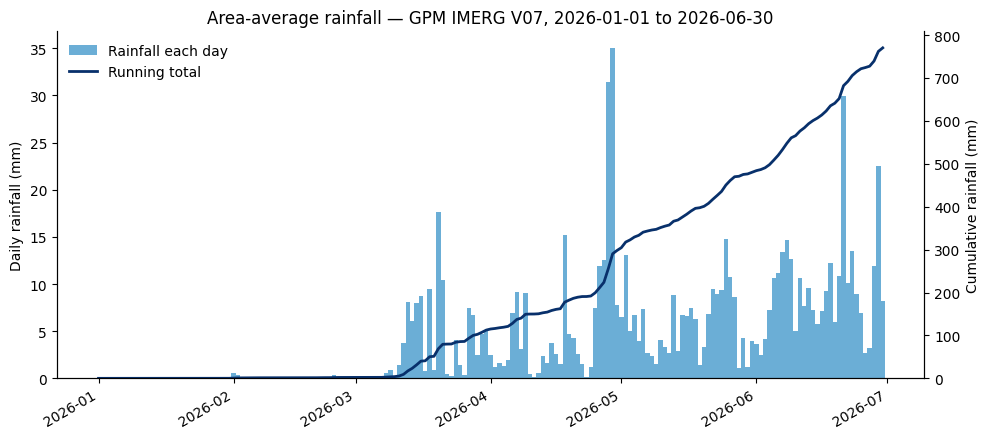

In [12]:
fig, ax = plt.subplots(figsize=(10, 4.5))

ax.bar(series["date"], series["rain_mm"], width=1.0,
       color="#6baed6", label="Rainfall each day")
ax.set_ylabel("Daily rainfall (mm)")
ax.set_ylim(bottom=0)

running = ax.twinx()
running.plot(series["date"], series["cumulative_mm"],
             color="#08306b", linewidth=2, label="Running total")
running.set_ylabel("Cumulative rainfall (mm)")
running.set_ylim(bottom=0)

ax.set_title(f"Area-average rainfall — {cfg['label']}, {START_DATE} to {END_DATE}")

handles = ax.get_legend_handles_labels()[0] + running.get_legend_handles_labels()[0]
labels = ax.get_legend_handles_labels()[1] + running.get_legend_handles_labels()[1]
ax.legend(handles, labels, loc="upper left", frameon=False)

for spine in ("top",):
    ax.spines[spine].set_visible(False)
    running.spines[spine].set_visible(False)

fig.autofmt_xdate()
fig.tight_layout()
plt.show()

### Keep the table

The chart is a picture of the numbers; this is the numbers. A CSV of daily and
cumulative rainfall drops straight into a report, a spreadsheet or a model.

In [13]:
csv_name = f"rainfall_daily_{DATA_SOURCE}_{START_DATE}_to_{END_DATE}.csv"
series.to_csv(csv_name, index=False)

print(f"Wrote {csv_name} — {len(series)} rows")
print("In Colab, open the folder icon in the left sidebar to download it.")

Wrote rainfall_daily_gpm_2026-01-01_to_2026-06-30.csv — 181 rows
In Colab, open the folder icon in the left sidebar to download it.


## 12. Take the numbers away with you

A picture is for looking at. For anything downstream — a report, a model input,
a GIS layer — you want the values.

### One number for the whole area

An area-average total, which is the figure that usually ends up in a bulletin.

In [14]:
area_mean = composite.reduceRegion(
    reducer=ee.Reducer.mean(),
    geometry=geometry,
    scale=cfg["native_scale"],
    maxPixels=1e9,
    bestEffort=True,
).getInfo()

print(f"Area-average {TEMPORAL_AGGREGATION} rainfall: "
      f"{area_mean[cfg['band']]:.1f} mm")

Area-average sum rainfall: 770.1 mm


### The grid, as a GeoTIFF

`Export.image.toDrive` starts a background task on Earth Engine's servers and
writes the result to your Google Drive. Watch it in the **Tasks** tab of the
[Code Editor](https://code.earthengine.google.com/), or with
`task.status()`. A large area can take several minutes.

See [exporting images](https://developers.google.com/earth-engine/guides/exporting_images)
for the other destinations, including Cloud Storage and Earth Engine assets.

In [15]:
task = ee.batch.Export.image.toDrive(
    image=composite,
    description=f"rainfall_{DATA_SOURCE}_{START_DATE}_{END_DATE}".replace("-", ""),
    folder="earthengine",
    scale=cfg["native_scale"],
    region=geometry,
    fileFormat="GeoTIFF",
    maxPixels=1e9,
)
task.start()

print(f"Export started: {task.id}")
print("Check progress with task.status(), or in the Tasks tab of the Code Editor.")

Export started: JOJBC27UJTIVLRLG6M44INDP
Check progress with task.status(), or in the Tasks tab of the Code Editor.


## 13. When it does not work

| What you see | What it means | What to do |
| --- | --- | --- |
| `EEException: Earth Engine API has not been used in project ... before or it is disabled` | The project ID is wrong, or the API is off | Check the ID in the [Cloud Resource Manager](https://console.cloud.google.com/cloud-resource-manager), then enable the [Earth Engine API](https://console.cloud.google.com/apis/library/earthengine.googleapis.com) for it |
| `... requires a quota project, which is not set by default` | Earth Engine cannot work out which project to bill | Pass `project=` to `ee.Initialize()`, or run `earthengine set_project YOUR_PROJECT_ID` |
| `Project has an incompatible OAuth2 Client configuration` | That project already has an OAuth client, and it cannot be removed | Authenticate against a different project. It does not have to be the one you compute in |
| `gcloud failed. Please check for any errors above` | `ee.Authenticate(auth_mode='gcloud')` was called inside a notebook | Call plain `ee.Authenticate()` and let it choose the mode |
| Computation timed out | Too many images, too large an area, or too fine a scale | Shorten the date range, shrink the box, or switch to CHIRPS — daily images instead of half-hourly is 48 times less to read |
| `Too many pixels in the region` | `reduceRegion` hit its limit | Add `bestEffort=True`, or pass a coarser `scale` |
| Blank map, no error | The date range is past the end of the archive, or outside its coverage | Re-run section 7. CHIRPS stops at 50°N and 50°S |
| Totals look twice as large as expected | GPM's mm/hr values were added without the 0.5 conversion | Section 6 |
| The chart cell times out | One reduction per day is a lot of requests | Shorten the window, shrink the box, or switch to CHIRPS |
| Gaps in the chart, or fewer rows than days | Those days had no usable data and were dropped | Expected near the end of the archive. Check the count printed in section 11 |

Google's [debugging guide](https://developers.google.com/earth-engine/guides/debugging)
covers the general case, and the
[google-earth-engine tag](https://gis.stackexchange.com/questions/tagged/google-earth-engine)
on GIS Stack Exchange is where most specific questions have already been asked
and answered.

## 14. Where to go next

**Change one thing at a time.** Swap `DATA_SOURCE` to `"chirps"` and re-run from
section 5 with the same dates and area. CHIRPS has finer pixels and a longer
record; GPM is more recent and sees sub-daily structure. Comparing the two
totals over a place you know is the fastest way to build a feel for both.

**Map dry spells instead of totalling.** Section 11 counted dry days for the
area as a whole. The same idea works pixel by pixel:
`days.map(lambda i: i.lt(1)).sum()` gives a map of how many dry days each place
had — closer to what an agricultural advisory needs than a seasonal total, and a
step towards the drought indicators the programme uses.

**Compare against a normal.** A total on its own is hard to act on. Run the same
window against the 1991–2020 CHIRPS record and the difference tells you whether
this season is unusual, which is what actually triggers a decision.

**Chart several places at once.** Replace the single `geometry` in section 11
with a `FeatureCollection` of districts and use
[`reduceRegions`](https://developers.google.com/earth-engine/guides/reducers_reduce_regions)
— one call returns a time series per district, which is the shape a bulletin
needs.

### On this site

- [GPM IMERG]({{ site.baseurl }}/datasets/gpm-imerg/) and
  [CHIRPS]({{ site.baseurl }}/datasets/chirps/) — how the programme uses each
- [Indicator generation]({{ site.baseurl }}/methods/indicator-generation/) — where
  accumulated rainfall sits among the drought and water-balance indicators
- [All datasets]({{ site.baseurl }}/datasets/) — the wider archive behind the S2S work

### Elsewhere

- [Earth Engine Python quickstart](https://developers.google.com/earth-engine/guides/quickstart_python)
- [Earth Engine Data Catalog](https://developers.google.com/earth-engine/datasets)
- [Coding best practices](https://developers.google.com/earth-engine/guides/best_practices) —
  read this before scaling anything up
- [geemap documentation](https://geemap.org/)

---

*This notebook is based on a rainfall accumulation script written for the
programme by Dhyey Bhatpuria, extended here with the registration steps, the
units conversion and the export.*